# Scoring systems under the supervenience Bayesian network

This explanatory technical notebook is the executable companion to **Section 7** of the paper [*From cacophony to hierarchy: a principled framework for assessing AI consciousness*](https://arxiv.org/abs/2609.35618): a Bayesian approach to assessing a system's consciousness that combines indicator evidence, theoretical credences about which level of description is the critical one, and the supervenience structure between levels.

_This notebook was updated (from a previous human-made but now outdated version) with extensive help from Fable 5, and was then reviewed by the authors._

> **New here, or not a programmer?** You don't need to run anything or read the code cells. The text and the figures below tell the whole story, so read straight down, skipping the grey code boxes. For a hands-on version with clickable buttons and sliders instead of code, try the [live interactive explorer](https://ai-cognition.org/cacophony-tool/).

## The model in one paragraph

For each Level $i \in \{1,\dots,5\}$ there is a Boolean node $C_i$ — *"the system instantiates, at Level $i$, the organisation that Level-$i$ theories take to suffice for consciousness"*. The nodes form a directed chain $C_5 \to C_4 \to C_3 \to C_2 \to C_1$ (each level is a coarse-graining of the one below it in the chain; the root is $C_5$, the organism-environment level). Each indicator $I_{i,k}$ is a child of its level node $C_i$. Every edge is a noisy channel characterised by a true-positive and a false-positive rate:

- **$\alpha_C = P(C_i = 1 \mid C_{i+1} = 1)$** — *supervenience strength*. The **Strict Supervenience Model** (paper §7.2.1) pins this to 1 (**Condition 2A**): consciousness at a finer level deterministically guarantees it at every coarser level, and the **monotonic belief property** $P(C_1|e) \geq \cdots \geq P(C_5|e)$ holds. The **generalised model** (§7.2.2) weakens this to $\alpha_C \leq 1$ (**Condition 2B**), here with prior $\mathrm{Beta}(8,2)$ (mean 0.8) — accommodating cases like the locked-in patient (conscious at Level 2, no Level 1 behavioural activation).
- **$\beta_C = P(C_i = 1 \mid C_{i+1} = 0)$** — the edge *false-positive rate* ("leak"): how often the coarser-level organisation is present although the finer level is absent. Prior $\mathrm{Beta}(2,8)$ (mean 0.2).
- **$\pi = P(C_5 = 1)$** — the root prior, with a four-shape Beta sweep for sensitivity analysis.
- **$\alpha_j, \beta_j$** — the same TPR/FPR pair for each indicator $I_j$ given its parent $C_i$, derived from the *support* and *demandingness* labels of the Digital Consciousness Model (DCM; Shiller et al., 2026, [arXiv:2601.17060](https://arxiv.org/abs/2601.17060)) (see `dcm priors/mapping.md`).

Under the generalised model all $2^5 = 32$ configurations of $(C_1,\dots,C_5)$ carry mass; under the strict model only the six "staircase" configurations survive. Finally (§7.3), the **overall credence** that a system is conscious is the theoretical-credence-weighted average $P(C\mid E) = \sum_i P(L^\ast = i)\, P(C_i \mid E)$, where $L^\ast$ is the critical level for consciousness.

In [1]:
import sys, pathlib
ROOT = pathlib.Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
FIG = ROOT / 'outputs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as _beta_dist

from dcm_lab.indicators import (
    load_indicators, alpha_beta_arrays, level_of_array,
    indicators_by_level, level_counts, DEFAULT_CSV_PATH,
)
from dcm_lab.truth import (
    L, C_PRIOR_SWEEP, C_ALPHA_PRIOR, C_BETA_PRIOR, make_prior_config,
)
from dcm_lab.score import (
    prior_predictive_score, prior_depth_distribution, prior_C_marginals,
    prior_C_from_depth, overall_credence, format_score, hdi_from_samples,
)

N_DRAWS = 5000
SEED = 0
HDI_PROB = 0.89

indicators = load_indicators(DEFAULT_CSV_PATH)
N_IND = len(indicators)
alpha_arr, beta_arr = alpha_beta_arrays(indicators)
level_of = level_of_array(indicators)   # 0-indexed level per indicator

def cfg_for(root_ab, strict=False):
    '''Prior config for a given root Beta shape (generalised unless strict=True).'''
    return make_prior_config(root_ab, alpha_arr, beta_arr, strict=strict)

print(f'Network: {L} levels, {N_IND} indicators.  Chain: C5 -> C4 -> C3 -> C2 -> C1 (root = C5).')
print('Indicators per level:')
for lvl, count in sorted(level_counts(indicators).items()):
    name = indicators_by_level(indicators)[lvl][0].level_name
    print(f'  Level {lvl} ({name}): {count} indicators')
print(f'\nEdge priors:  alpha_C ~ Beta{C_ALPHA_PRIOR} (mean {C_ALPHA_PRIOR[0]/sum(C_ALPHA_PRIOR):.2f}) '
      f'·  beta_C ~ Beta{C_BETA_PRIOR} (mean {C_BETA_PRIOR[0]/sum(C_BETA_PRIOR):.2f})')
print(f'Monte-Carlo draws per prior: {N_DRAWS};  HDI band probability: {HDI_PROB}')

Network: 5 levels, 37 indicators.  Chain: C5 -> C4 -> C3 -> C2 -> C1 (root = C5).
Indicators per level:
  Level 1 (Behavioural): 9 indicators
  Level 2 (Computational functional): 7 indicators
  Level 3 (Intrinsic causal-structure functional): 7 indicators
  Level 4 (Organismic functional): 6 indicators
  Level 5 (Organism-environment (4E) functional): 8 indicators

Edge priors:  alpha_C ~ Beta(8.0, 2.0) (mean 0.80) ·  beta_C ~ Beta(2.0, 8.0) (mean 0.20)
Monte-Carlo draws per prior: 5000;  HDI band probability: 0.89


## 1. The supervenience chain

The five levels run from C1 (Behavioural, the most coarse-grained) down to C5 (Organism-environment / 4E, the most fine-grained). Each Level $i$ is a coarse-graining of Level $i{+}1$; equivalently, each coarser level **supervenes** on the finer one below it. The chain is rooted at C5 and probability flows up toward behaviour:

```
   C5 (Organism-environment / 4E)      <- root  pi = P(C5 = 1)
    |   alpha_C / beta_C
    v
   C4 (Organismic)
    |   alpha_C / beta_C
    v
   C3 (Intrinsic causal-structure)
    |   alpha_C / beta_C
    v
   C2 (Computational functional)
    |   alpha_C / beta_C
    v
   C1 (Behavioural)
```

Each edge is a noisy channel:

- with probability **$\alpha_C$** the coarser level is on *given the finer level is on* (supervenience strength — the summary agrees with the details);
- with probability **$\beta_C$** the coarser level is on *given the finer level is off* (the leak — e.g. behaviour produced without the underlying computational organisation).

Under **Condition 2A** ($\alpha_C = 1$, the Strict Supervenience Model) a finer level being on *guarantees* every coarser level above it, so the on-set is always downward-closed $\{C_1 \dots C_m\}$ — the 6 staircase configurations, with a well-defined *depth* (the highest active level). Under **Condition 2B** ($\alpha_C \leq 1$, the generalised model) the chain can break — e.g. a Level 2 activation without the Level 1 behavioural activation (the locked-in case) — opening the full $2^5 = 32$ configuration space. Indicators hang off each level as children of their $C_i$.

## 2. Where the indicator priors come from

For each of the 37 indicators we have

- $\alpha_j = P(I_j = 1 \mid \text{parent } C_i = 1)$ — true-positive rate, and
- $\beta_j = P(I_j = 1 \mid \text{parent } C_i = 0)$ — false-positive rate,

derived from the DCM's *support* and *demandingness* labels for each indicator's closest DCM analogue (`dcm priors/mapping.md` documents the conversion; this reuse is a first approximation to illustrate model behaviour). 

(Note we deliberately echo the notation: the indicator edges and the C-layer edges are both TPR/FPR channels — $\alpha$ for "on given parent on", $\beta$ for "on given parent off". Below, the per-indicator $(\alpha, \beta)$ coloured by level.)

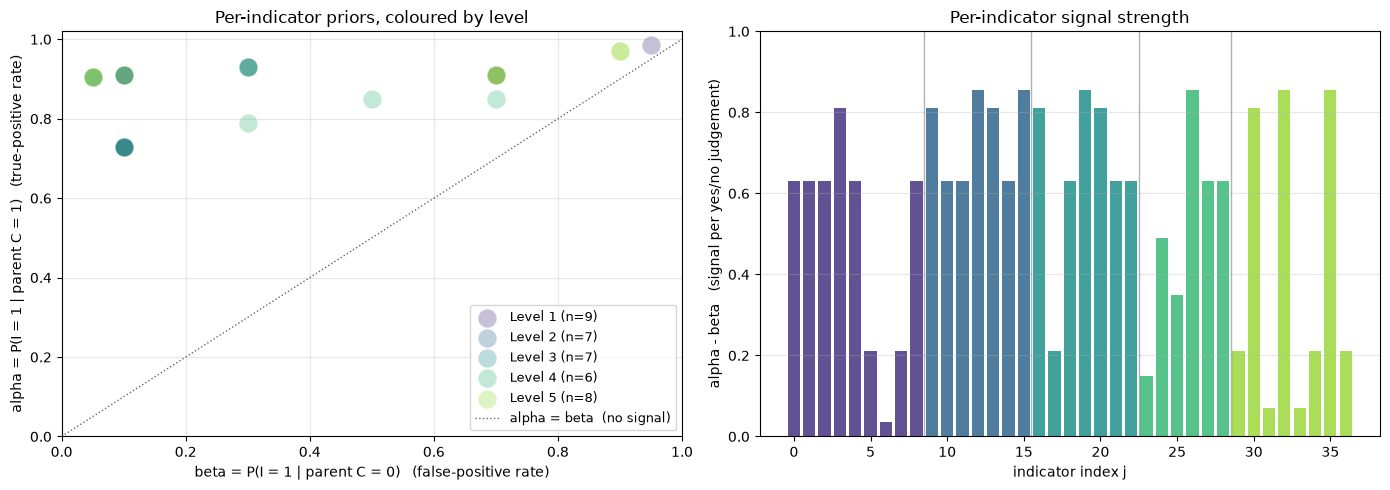

In [2]:
level_colors = plt.cm.viridis(np.linspace(0.15, 0.85, L))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for lvl in range(1, L + 1):
    sel = [i for i, ind in enumerate(indicators) if ind.level == lvl]
    ax.scatter(beta_arr[sel], alpha_arr[sel], s=180, color=level_colors[lvl - 1],
               edgecolor='white', linewidth=0.6, alpha=0.30,
               label=f'Level {lvl} (n={len(sel)})')
ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.6, label='alpha = beta  (no signal)')
ax.set_xlabel('beta = P(I = 1 | parent C = 0)   (false-positive rate)')
ax.set_ylabel('alpha = P(I = 1 | parent C = 1)   (true-positive rate)')
ax.set_title('Per-indicator priors, coloured by level')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
gap = alpha_arr - beta_arr
bar_colors = [level_colors[level_of[j]] for j in range(N_IND)]
ax.bar(np.arange(N_IND), gap, color=bar_colors, alpha=0.85)
boundary = 0
for lvl in range(1, L):
    boundary += level_counts(indicators)[lvl]
    ax.axvline(boundary - 0.5, color='black', alpha=0.3, lw=1)
ax.set_xlabel('indicator index j')
ax.set_ylabel('alpha - beta   (signal per yes/no judgement)')
ax.set_title('Per-indicator signal strength')
ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / 'indicator_priors.png', dpi=120, bbox_inches='tight')
plt.show()

Reading the figure:

- **Most indicators sit well above the diagonal** — `α > β` substantially — so each carries real evidence about whether the parent C-node is on.
- **A few indicators sit close to the top-right corner** (`α ≈ β ≈ 0.9`). These are 'undemanding' features that fire frequently regardless of consciousness — they're noisy and contribute little. The DCM acknowledges this and the model here accordingly makes likelihood ratio `α/(1-α)` vs `β/(1-β)` close to 1 for these.
- **Cluster around (0.10, 0.73)**: the nine 'fallback' rows where we had no clean DCM mapping. These behave as neutral, moderately informative indicators.

The full per-indicator table (truncated to the columns that are needed for scoring) is below:

In [3]:
table = pd.DataFrame({
    'j':       [i.j for i in indicators],
    'level':   [i.level for i in indicators],
    'name':    [i.name for i in indicators],
    'alpha':   alpha_arr.round(3),
    'beta':    beta_arr.round(3),
    'gap':     (alpha_arr - beta_arr).round(3),
})
table

,j,level,name,alpha,beta,gap
0,0,1,Consciousness Turing Test (CTT),0.730,0.10,0.630
1,1,1,Standard Turing-style imitation CTT,0.730,0.10,0.630
2,2,1,Garland-style transparent CTT,0.730,0.10,0.630
3,3,1,Coherence across contexts and time,0.910,0.10,0.810
4,4,1,Appropriate scaling of responses,0.730,0.10,0.630
5,5,1,Resistance to overriding reported internal states,0.910,0.70,0.210
6,6,1,Unprompted spontaneous behaviour,0.985,0.95,0.035
7,7,1,Coupling between reported states and subsequen...,0.910,0.70,0.210
8,8,1,Quasi-subjecthood,0.730,0.10,0.630
9,9,2,Information integration,0.910,0.10,0.810


## 3. The C-layer priors: supervenience strength $\alpha_C$ and leak $\beta_C$

The edge parameters live on the four edges of the chain. We share one prior across all four edges (each edge draws independently):

- **$\alpha_C \sim \mathrm{Beta}(8, 2)$** (mean 0.8) — supervenience usually holds, but not perfectly (Condition 2B). Set $\alpha_C = 1$ for the **Strict Supervenience Model** (Condition 2A).
- **$\beta_C \sim \mathrm{Beta}(2, 8)$** (mean 0.2) — the edge false-positive rate is usually small but non-zero.
- **$\pi = P(C_5 = 1)$** — root prior, swept over four shapes. (The choice of uniform prior below was Beta(1,1), but we also advise users trying the Beta (1/2, 1/2) instead)

A neat consequence: under a $\mathrm{Beta}(1,1)$ root and these edge means, every level's *prior* marginal sits at $\approx 0.5$, because $\tfrac12 \mathbb{E}[\alpha_C] + \tfrac12 \mathbb{E}[\beta_C] = \tfrac12(0.8 + 0.2) = 0.5$. The figure shows the edge densities, and the induced per-level and depth distributions under the **generalised** vs **strict** models (root $\mathrm{Beta}(1,1)$).

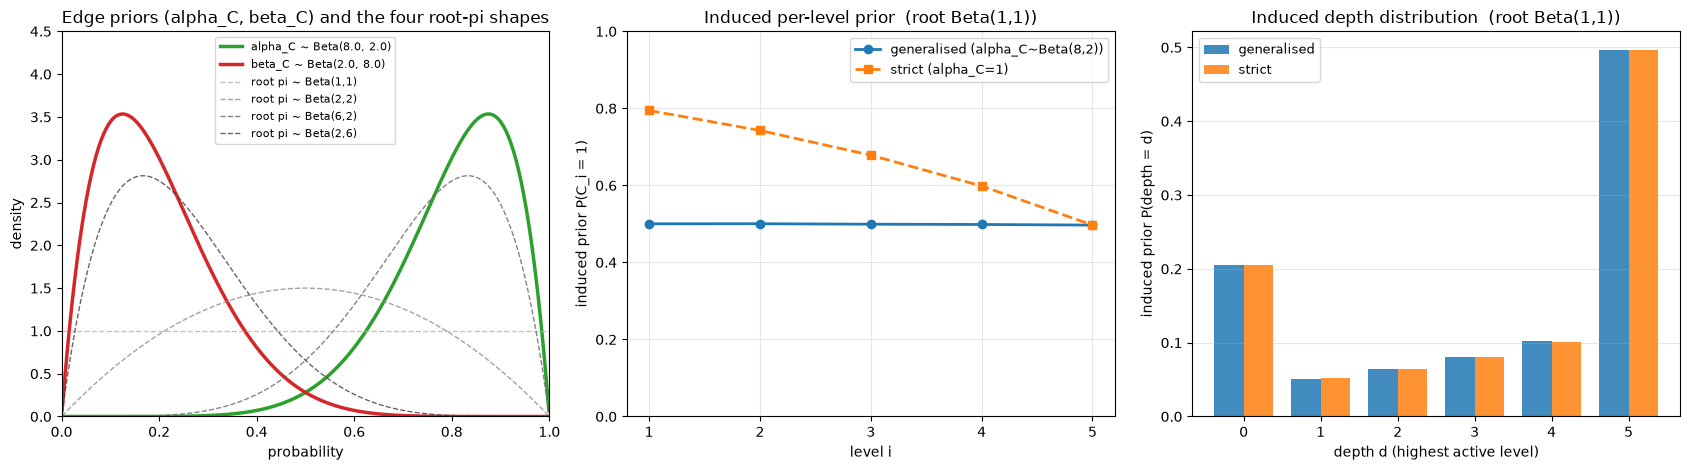

In [4]:
xs = np.linspace(0.001, 0.999, 400)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# Panel 1: the edge densities + the four root shapes.
ax = axes[0]
ax.plot(xs, _beta_dist.pdf(xs, *C_ALPHA_PRIOR), 'C2', lw=2.5, label=f'alpha_C ~ Beta{C_ALPHA_PRIOR}')
ax.plot(xs, _beta_dist.pdf(xs, *C_BETA_PRIOR), 'C3', lw=2.5, label=f'beta_C ~ Beta{C_BETA_PRIOR}')
for (lab, ab), c in zip(C_PRIOR_SWEEP, ['0.7', '0.55', '0.4', '0.25']):
    ax.plot(xs, _beta_dist.pdf(xs, *ab), color=c, lw=1, ls='--', alpha=0.8,
            label=f'root pi ~ {lab}')
ax.set_xlim(0, 1); ax.set_ylim(0, 4.5)
ax.set_xlabel('probability'); ax.set_ylabel('density')
ax.set_title('Edge priors (alpha_C, beta_C) and the four root-pi shapes')
ax.legend(fontsize=8)

# Panel 2: induced prior P(C_i = 1) per level, generalised vs strict (root Beta(1,1)).
ax = axes[1]
xk = np.arange(1, L + 1)
pm_gen = prior_C_marginals(cfg_for((1.0, 1.0), strict=False), n_draws=20000, seed=SEED)
pm_str = prior_C_marginals(cfg_for((1.0, 1.0), strict=True),  n_draws=20000, seed=SEED)
ax.plot(xk, pm_gen, 'o-', color='C0', lw=2, label='generalised (alpha_C~Beta(8,2))')
ax.plot(xk, pm_str, 's--', color='C1', lw=2, label='strict (alpha_C=1)')
ax.set_xticks(xk); ax.set_ylim(0, 1)
ax.set_xlabel('level i'); ax.set_ylabel('induced prior P(C_i = 1)')
ax.set_title('Induced per-level prior  (root Beta(1,1))')
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# Panel 3: induced depth distribution, generalised vs strict.
ax = axes[2]
xd = np.arange(L + 1); w = 0.38
dep_gen = prior_depth_distribution(cfg_for((1.0, 1.0), strict=False), n_draws=20000, seed=SEED)
dep_str = prior_depth_distribution(cfg_for((1.0, 1.0), strict=True),  n_draws=20000, seed=SEED)
ax.bar(xd - w/2, dep_gen, width=w, color='C0', alpha=0.85, label='generalised')
ax.bar(xd + w/2, dep_str, width=w, color='C1', alpha=0.85, label='strict')
ax.set_xticks(xd)
ax.set_xlabel('depth d (highest active level)'); ax.set_ylabel('induced prior P(depth = d)')
ax.set_title('Induced depth distribution  (root Beta(1,1))')
ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG / 'cedge_priors.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. How a single case is scored

**Step 1 — enumerate configurations.** We enumerate all $2^5 = 32$ configurations of $(C_1,\dots,C_5)$. (Under the Strict Supervenience Model the non-staircase configurations simply receive $\sim$zero prior, recovering the 6 staircases.)

**Step 2 — per-configuration likelihood.** Each indicator $j$ contributes $\alpha_j$ / $1{-}\alpha_j$ if its level is on in the configuration, else $\beta_j$ / $1{-}\beta_j$. Multiply across all 37 (sum of logs) $\to \log P(e \mid \text{config})$. $\theta$-independent.

**Step 3 — per-configuration prior (bottom-up).** For each draw of $\theta = (\pi, \alpha_C, \beta_C)$:
```
P(config | theta) = [pi if C5=1 else 1-pi] * prod_{i=1..4} P(C_i | C_{i+1})
   with  P(C_i=1 | C_{i+1}=1) = alpha_C,   P(C_i=1 | C_{i+1}=0) = beta_C.
```

**Step 4 — combine and average.** Multiply prior × likelihood, normalise across the 32 configurations, average over the `N_DRAWS` draws. The **per-level posteriors** $P(C_i = 1 \mid e)$ are obtained by summing the posterior over configurations with $C_i = 1$ — the primary, always-valid quantity. **Depth** (= highest active level) is reported too; under the strict model it fully describes the configuration, while under the generalised model it is a lossy summary (a configuration can have gaps below its top level).

The helper `prior_predictive_score(e, prior_config, level_of, ...)` does all four steps. Let's score a deliberately ambiguous case (about half the indicators on at every level) under both models:

In [5]:
def e_from_fractions(fractions):
    '''37-vector with round(f * n_lvl) yeses at the start of each level's block.'''
    e = np.zeros(N_IND, dtype=int)
    by_lvl = indicators_by_level(indicators)
    for k_idx, f in enumerate(fractions):
        idxs = [i.j for i in by_lvl.get(k_idx + 1, [])]
        for j in idxs[:int(round(f * len(idxs)))]:
            e[j] = 1
    return e

e_demo = e_from_fractions([0.5, 0.5, 0.5, 0.5, 0.5])
prior_C_gen = prior_C_marginals(cfg_for((1.0, 1.0)), n_draws=N_DRAWS, seed=SEED)
prior_dep_gen = prior_depth_distribution(cfg_for((1.0, 1.0)), n_draws=N_DRAWS, seed=SEED)

for label, strict in [('GENERALISED  (Condition 2B: alpha_C~Beta(8,2))', False),
                      ('STRICT       (Condition 2A: alpha_C = 1)', True)]:
    sc = prior_predictive_score(e_demo, cfg_for((1.0, 1.0), strict=strict), level_of,
                                n_draws=N_DRAWS, seed=SEED)
    print('=' * 66)
    print(f'{label}   — root Beta(1,1), case = half-yes everywhere')
    print(format_score(sc, prior_depth=prior_dep_gen, prior_C=prior_C_gen))

GENERALISED  (Condition 2B: alpha_C~Beta(8,2))   — root Beta(1,1), case = half-yes everywhere
Per-level posteriors P(C_i = 1 | e):
  C1: 0.944  ######################################    prior = 0.499
  C2: 0.914  #####################################    prior = 0.499
  C3: 0.777  ###############################    prior = 0.499
  C4: 0.071  ###    prior = 0.498
  C5: 0.242  ##########    prior = 0.498

Posterior over depth (highest active level):
  depth = 0: 0.017  #    prior = 0.206
  depth = 1: 0.036  #    prior = 0.052
  depth = 2: 0.126  #####    prior = 0.064
  depth = 3: 0.565  #######################    prior = 0.080
  depth = 4: 0.014  #    prior = 0.100
  depth = 5: 0.242  ##########    prior = 0.498

Most likely depth: 3
STRICT       (Condition 2A: alpha_C = 1)   — root Beta(1,1), case = half-yes everywhere
Per-level posteriors P(C_i = 1 | e):
  C1: 0.987  #######################################    prior = 0.499
  C2: 0.958  ######################################    prior = 

## 5. Strict vs generalised — what relaxing Condition 2A gets us

Under the Strict Supervenience Model the on-set is downward-closed: if a level is on, every coarser level above it is on. The **monotonic belief property** follows: $P(C_1|e) \geq P(C_2|e) \geq \cdots \geq P(C_5|e)$ exactly, and all posterior mass sits on the 6 staircases — a Level-1 behaviourist ends up at least as confident as a Level-5 4E theorist, whatever the evidence. Weakening $\alpha_C$ below 1 (Condition 2B) lets the chain **break**: a system can register a finer level without a coarser one, or vice-versa — the locked-in patient (Level 2 without Level 1), or an organism with rich organismic regulation but no metacognition.

The plot below scores one case under both models, and shows (left) the per-level posteriors — monotone under strict, non-monotone under generalised — and (right) how much posterior mass lands on **non-staircase** configurations, mass that is structurally impossible under Condition 2A.

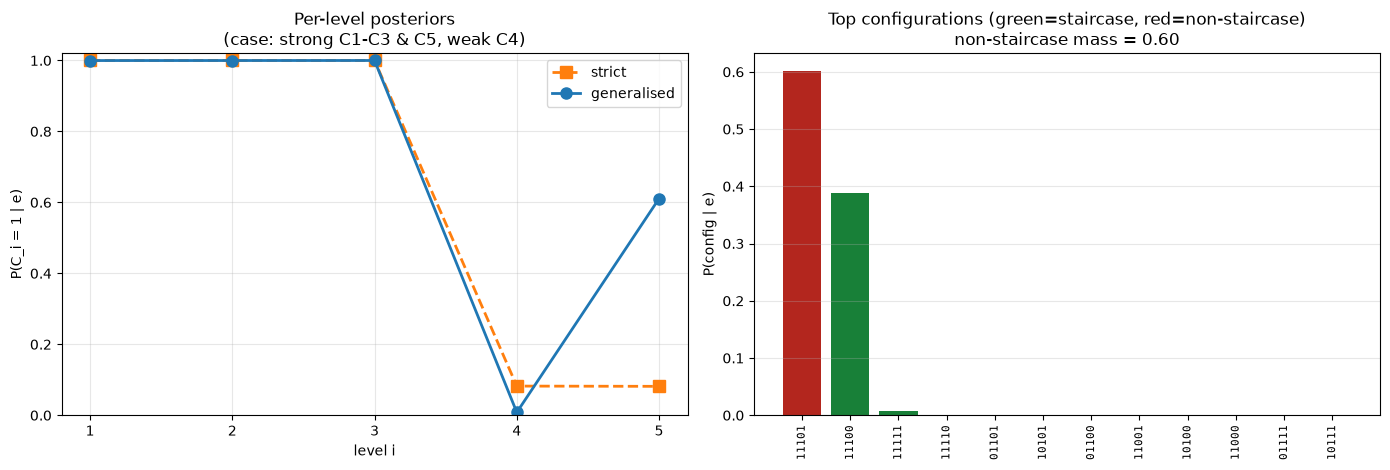

Non-staircase posterior mass (generalised): 0.603
Config string is C1C2C3C4C5 (1=on).


In [6]:
def is_staircase(cfg):
    m = sum(cfg)
    return list(cfg) == [1] * m + [0] * (L - m)

from dcm_lab.score import _enumerate_configs_full
ALL_CFG = _enumerate_configs_full(L)
STAIR = np.array([is_staircase(c) for c in ALL_CFG])

# A case that should produce a 'gap': strong at the fine-grained end (C5) and the
# coarse end (C1-C3) but weak on the organismic middle (C4) — the kind of profile
# the strict model cannot represent.
e_gap = e_from_fractions([0.7, 0.7, 0.8, 0.1, 0.8])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
level_colors = plt.cm.viridis(np.linspace(0.15, 0.85, L))
xk = np.arange(1, L + 1)

# Left: per-level posteriors, strict vs generalised.
ax = axes[0]
for label, strict, mk, c in [('strict', True, 's--', 'C1'), ('generalised', False, 'o-', 'C0')]:
    sc = prior_predictive_score(e_gap, cfg_for((1.0, 1.0), strict=strict), level_of,
                                n_draws=N_DRAWS, seed=SEED, return_per_theta=True)
    means = sc['P(C_i=1|e,theta)_per_draw'].mean(axis=0)
    ax.plot(xk, means, mk, color=c, lw=2, markersize=8, label=label)
ax.set_xticks(xk); ax.set_ylim(0, 1.02)
ax.set_xlabel('level i'); ax.set_ylabel('P(C_i = 1 | e)')
ax.set_title('Per-level posteriors\n(case: strong C1-C3 & C5, weak C4)')
ax.grid(alpha=0.3); ax.legend()

# Right: posterior mass on staircase vs non-staircase configs (generalised).
ax = axes[1]
from dcm_lab.score import _sample_edge_logprobs
cfg_mat, depth_idx, log_p_cfg = _sample_edge_logprobs(cfg_for((1.0, 1.0)), N_DRAWS, SEED)
m1 = np.where(e_gap == 1, alpha_arr, 1 - alpha_arr); m0 = np.where(e_gap == 1, beta_arr, 1 - beta_arr)
lt1 = np.zeros(L); lt0 = np.zeros(L)
for j in range(N_IND):
    lt1[level_of[j]] += np.log(max(m1[j], 1e-300)); lt0[level_of[j]] += np.log(max(m0[j], 1e-300))
log_lik = cfg_mat @ lt1 + (1 - cfg_mat) @ lt0
lj = log_p_cfg + log_lik[None, :]; lj -= lj.max(1, keepdims=True)
joint = np.exp(lj); joint /= joint.sum(1, keepdims=True)
p_cfg = joint.mean(0)                                   # P(config | e), length 32
order = np.argsort(p_cfg)[::-1][:12]
bar_c = ['#188038' if STAIR[i] else '#b3261e' for i in order]
labels = [''.join(str(b) for b in ALL_CFG[i]) for i in order]
ax.bar(range(len(order)), p_cfg[order], color=bar_c)
ax.set_xticks(range(len(order))); ax.set_xticklabels(labels, rotation=90, fontsize=8, family='monospace')
ax.set_ylabel('P(config | e)')
ax.set_title(f'Top configurations (green=staircase, red=non-staircase)\n'
             f'non-staircase mass = {p_cfg[~STAIR].sum():.2f}')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / 'strict_vs_generalised.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Non-staircase posterior mass (generalised): {p_cfg[~STAIR].sum():.3f}')
print('Config string is C1C2C3C4C5 (1=on).')

## 6. A root-$\pi$ sweep

The four-shape Beta sweep sits on the root $\pi = P(C_5 = 1)$. We look at the induced per-level and depth distributions for the **generalised** model. Because the edge means keep each level's prior near 0.5 under a flat root, the sweep mostly slides the whole stack up ($\mathrm{Beta}(6,2)$, deep-favouring) or down ($\mathrm{Beta}(2,6)$, shallow-favouring).

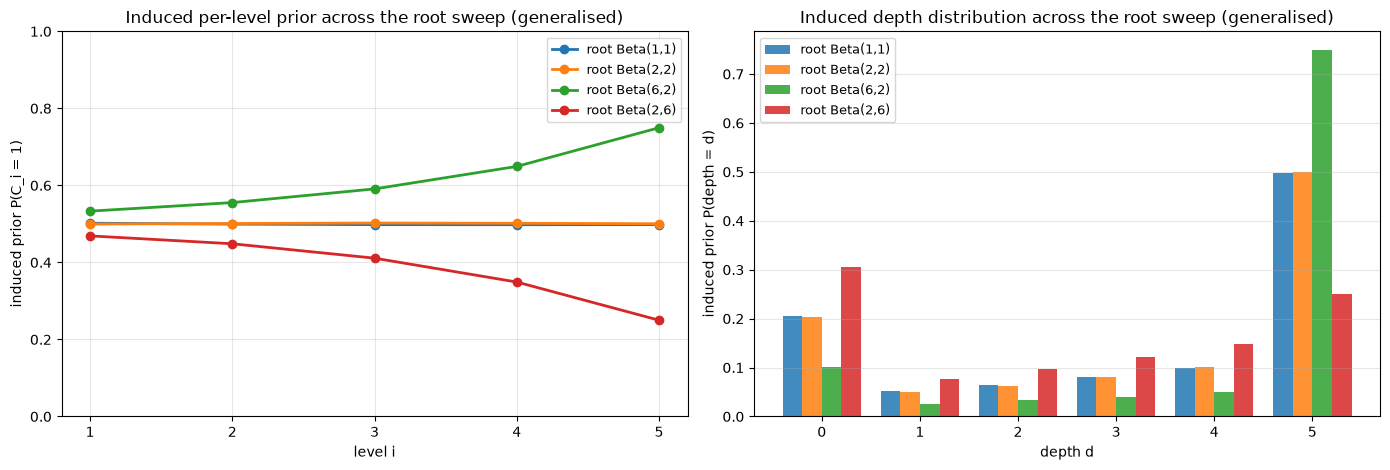

In [7]:
colors = ['C0', 'C1', 'C2', 'C3']
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
for (label, ab), c in zip(C_PRIOR_SWEEP, colors):
    pm = prior_C_marginals(cfg_for(ab), n_draws=10000, seed=SEED)
    ax.plot(np.arange(1, L + 1), pm, 'o-', color=c, lw=2, label=f'root {label}')
ax.set_xticks(np.arange(1, L + 1)); ax.set_ylim(0, 1)
ax.set_xlabel('level i'); ax.set_ylabel('induced prior P(C_i = 1)')
ax.set_title('Induced per-level prior across the root sweep (generalised)')
ax.grid(alpha=0.3); ax.legend(fontsize=9)

ax = axes[1]
xd = np.arange(L + 1); w = 0.2
for i, ((label, ab), c) in enumerate(zip(C_PRIOR_SWEEP, colors)):
    dep = prior_depth_distribution(cfg_for(ab), n_draws=10000, seed=SEED)
    ax.bar(xd + (i - 1.5) * w, dep, width=w, color=c, alpha=0.85, label=f'root {label}')
ax.set_xticks(xd)
ax.set_xlabel('depth d'); ax.set_ylabel('induced prior P(depth = d)')
ax.set_title('Induced depth distribution across the root sweep (generalised)')
ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG / 'root_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Five stylised test cases

Five hand-rolled evidence vectors (specified by the fraction of yeses per level), scored under the generalised model.

In [8]:
CASES = [
    ('A: mostly yes everywhere (~80% per level)',          [0.80, 0.80, 0.80, 0.80, 0.80]),
    ('B: strong on levels 1-2, weak below',                [0.80, 0.80, 0.15, 0.15, 0.15]),
    ('C: all no',                                          [0.00, 0.00, 0.00, 0.00, 0.00]),
    ('D: strong on levels 1-4, weak on level 5',           [0.80, 0.80, 0.80, 0.80, 0.20]),
    ('E: about half yes everywhere (the ambiguous one)',   [0.50, 0.50, 0.50, 0.50, 0.50]),
]
for name, frac in CASES:
    e = e_from_fractions(frac)
    counts = [int(e[level_of == k].sum()) for k in range(L)]
    sizes  = [int((level_of == k).sum())  for k in range(L)]
    print(f'{name:55s}   yes per level: [' +
          ', '.join(f'{c}/{s}' for c, s in zip(counts, sizes)) + ']')

A: mostly yes everywhere (~80% per level)                 yes per level: [7/9, 6/7, 6/7, 5/6, 6/8]
B: strong on levels 1-2, weak below                       yes per level: [7/9, 6/7, 1/7, 1/6, 1/8]
C: all no                                                 yes per level: [0/9, 0/7, 0/7, 0/6, 0/8]
D: strong on levels 1-4, weak on level 5                  yes per level: [7/9, 6/7, 6/7, 5/6, 2/8]
E: about half yes everywhere (the ambiguous one)          yes per level: [4/9, 4/7, 4/7, 3/6, 4/8]


### Example E, expanded across the root sweep (generalised model)

In [9]:
case_name, frac = CASES[4]
e_demo = e_from_fractions(frac)
print(f'Input: {case_name}\n')
for label, ab in C_PRIOR_SWEEP:
    sc = prior_predictive_score(e_demo, cfg_for(ab), level_of, n_draws=N_DRAWS, seed=SEED)
    prior_dep = prior_depth_distribution(cfg_for(ab), n_draws=N_DRAWS, seed=SEED)
    prior_C   = prior_C_marginals(cfg_for(ab), n_draws=N_DRAWS, seed=SEED)
    print('=' * 70)
    print(f'root pi = {label}')
    print(format_score(sc, prior_depth=prior_dep, prior_C=prior_C))

Input: E: about half yes everywhere (the ambiguous one)

root pi = Beta(1,1)
Per-level posteriors P(C_i = 1 | e):
  C1: 0.944  ######################################    prior = 0.499
  C2: 0.914  #####################################    prior = 0.499
  C3: 0.777  ###############################    prior = 0.499
  C4: 0.071  ###    prior = 0.498
  C5: 0.242  ##########    prior = 0.498

Posterior over depth (highest active level):
  depth = 0: 0.017  #    prior = 0.206
  depth = 1: 0.036  #    prior = 0.052
  depth = 2: 0.126  #####    prior = 0.064
  depth = 3: 0.565  #######################    prior = 0.080
  depth = 4: 0.014  #    prior = 0.100
  depth = 5: 0.242  ##########    prior = 0.498

Most likely depth: 3
root pi = Beta(2,2)
Per-level posteriors P(C_i = 1 | e):
  C1: 0.944  ######################################    prior = 0.499
  C2: 0.914  #####################################    prior = 0.499
  C3: 0.776  ###############################    prior = 0.500
  C4: 0.061  ##    

root pi = Beta(2,6)
Per-level posteriors P(C_i = 1 | e):
  C1: 0.943  ######################################    prior = 0.467
  C2: 0.911  ####################################    prior = 0.446
  C3: 0.767  ###############################    prior = 0.410
  C4: 0.032  #    prior = 0.350
  C5: 0.069  ###    prior = 0.252

Posterior over depth (highest active level):
  depth = 0: 0.021  #    prior = 0.307
  depth = 1: 0.044  ##    prior = 0.077
  depth = 2: 0.154  ######    prior = 0.096
  depth = 3: 0.694  ############################    prior = 0.120
  depth = 4: 0.017  #    prior = 0.149
  depth = 5: 0.069  ###    prior = 0.252

Most likely depth: 3


## 8. Full sweep — 5 cases × 4 root-priors (generalised model)

Coloured dot = across-$\theta$ mean, band = 89% HDI, black dotted = prior. Recall that $\theta$ represents the set of all model parameters, including edge strengths and indicator reliabilities.

In [10]:
results = {}
for case_name, frac in CASES:
    e = e_from_fractions(frac)
    results[case_name] = {}
    for label, ab in C_PRIOR_SWEEP:
        sc = prior_predictive_score(e, cfg_for(ab), level_of, n_draws=N_DRAWS, seed=SEED,
                                    return_per_theta=True)
        results[case_name][label] = {
            'P_C_per_theta':   sc['P(C_i=1|e,theta)_per_draw'],
            'P_C_prior':       prior_C_marginals(cfg_for(ab), n_draws=N_DRAWS, seed=SEED),
            'P_dep_per_theta': sc['P(depth=d|e,theta)_per_draw'],
            'P_dep_prior':     prior_depth_distribution(cfg_for(ab), n_draws=N_DRAWS, seed=SEED),
        }
print('Computed.')

Computed.


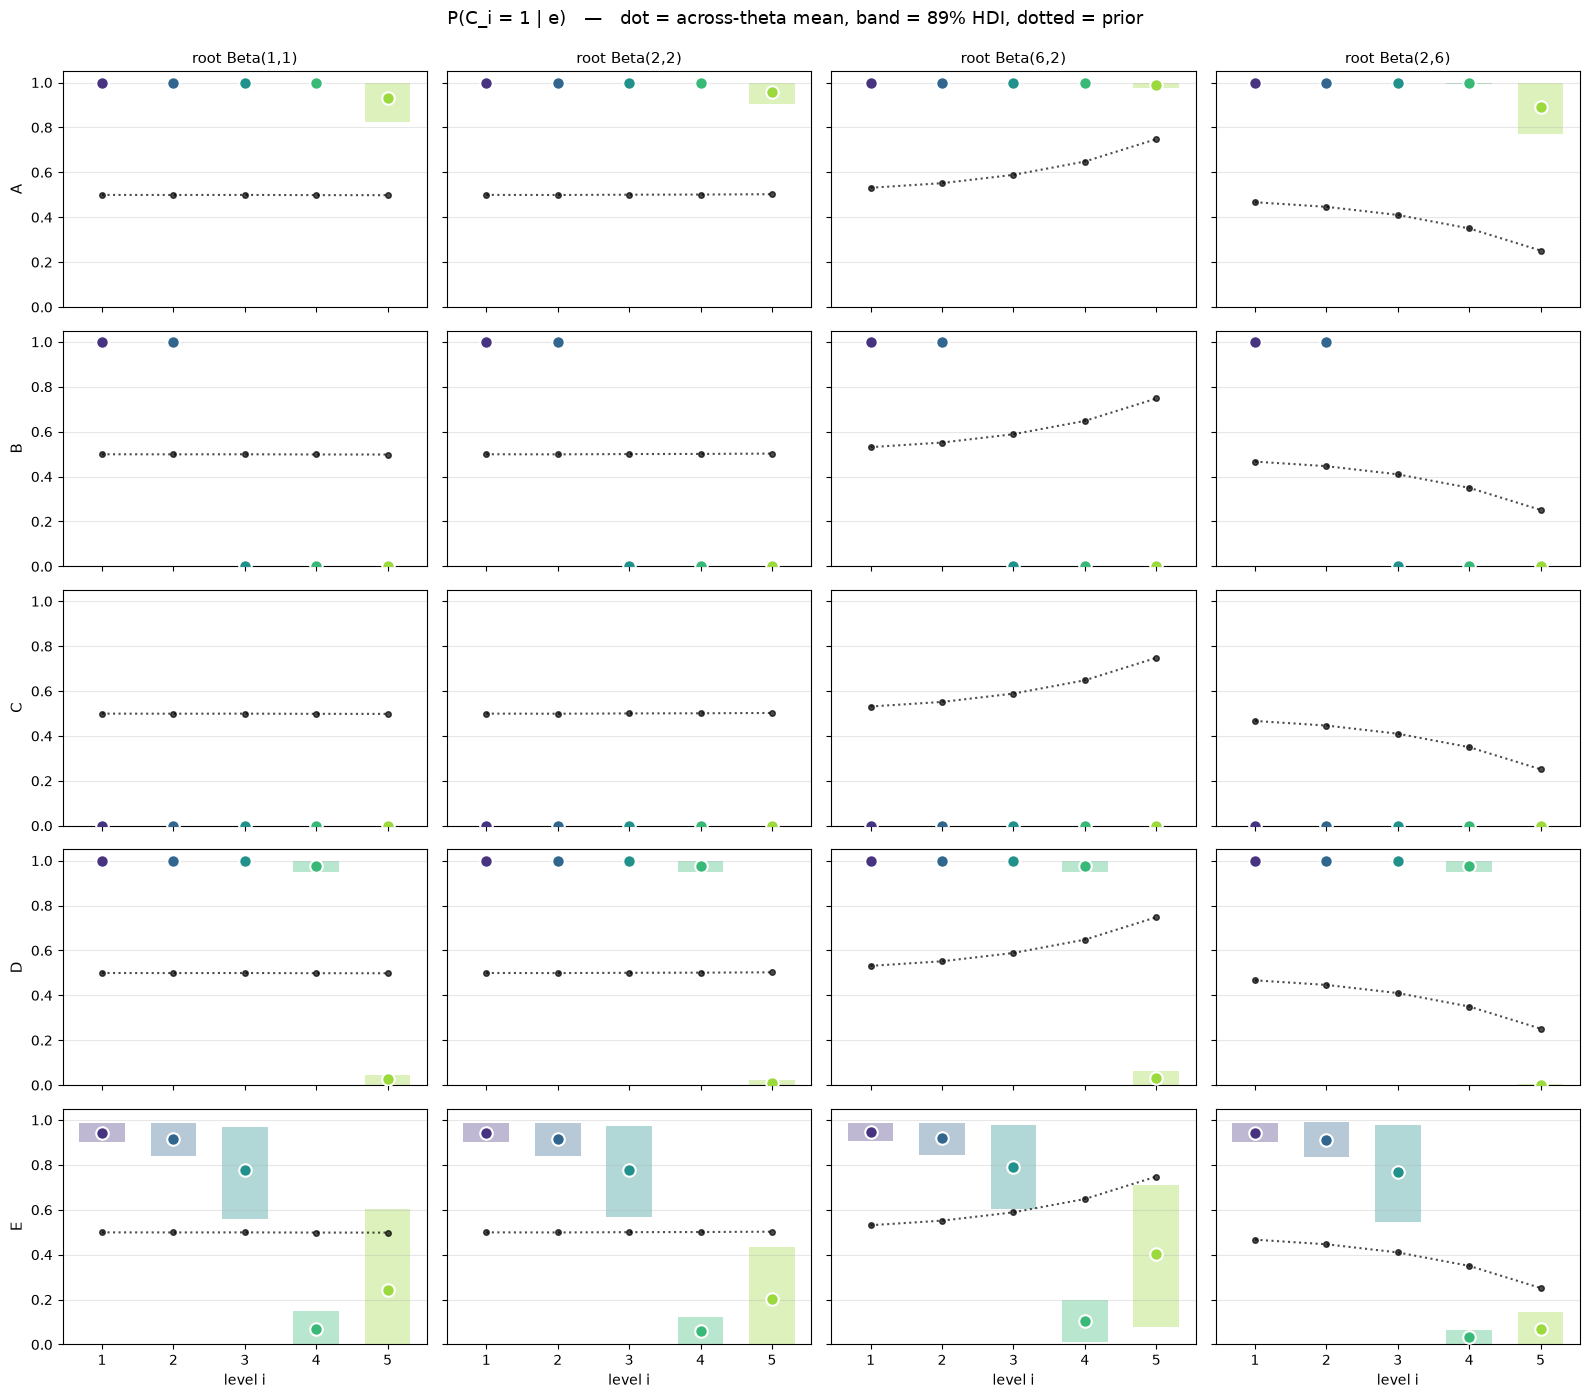

In [11]:
level_colors = plt.cm.viridis(np.linspace(0.15, 0.85, L))
fig, axes = plt.subplots(len(CASES), len(C_PRIOR_SWEEP), figsize=(16, 14), sharex=True, sharey=True)
xs = np.arange(1, L + 1); bh = 0.32
for i, (case_name, _) in enumerate(CASES):
    for j, (label, _) in enumerate(C_PRIOR_SWEEP):
        ax = axes[i, j]; r = results[case_name][label]
        per = r['P_C_per_theta']; means = per.mean(0)
        lo, hi = hdi_from_samples(per, prob=HDI_PROB, axis=0)
        for k in range(L):
            ax.fill_between([xs[k]-bh, xs[k]+bh], lo[k], hi[k], color=level_colors[k], alpha=0.35, lw=0)
            ax.plot(xs[k], means[k], 'o', color=level_colors[k], markersize=9,
                    markeredgecolor='white', markeredgewidth=1.5, zorder=3)
        ax.plot(xs, r['P_C_prior'], 'k:o', lw=1.5, markersize=4, alpha=0.7)
        ax.set_ylim(0, 1.05); ax.set_xticks(xs)
        if i == 0: ax.set_title(f'root {label}', fontsize=11)
        if j == 0: ax.set_ylabel(case_name.split(':')[0], fontsize=11)
        if i == len(CASES) - 1: ax.set_xlabel('level i')
        ax.grid(axis='y', alpha=0.3)
plt.suptitle(f'P(C_i = 1 | e)   —   dot = across-theta mean, band = {int(HDI_PROB*100)}% HDI, dotted = prior',
             y=0.995, fontsize=13)
plt.tight_layout()
plt.savefig(FIG / f'sweep_per_level_hdi{int(HDI_PROB*100)}.png', dpi=120, bbox_inches='tight')
plt.show()

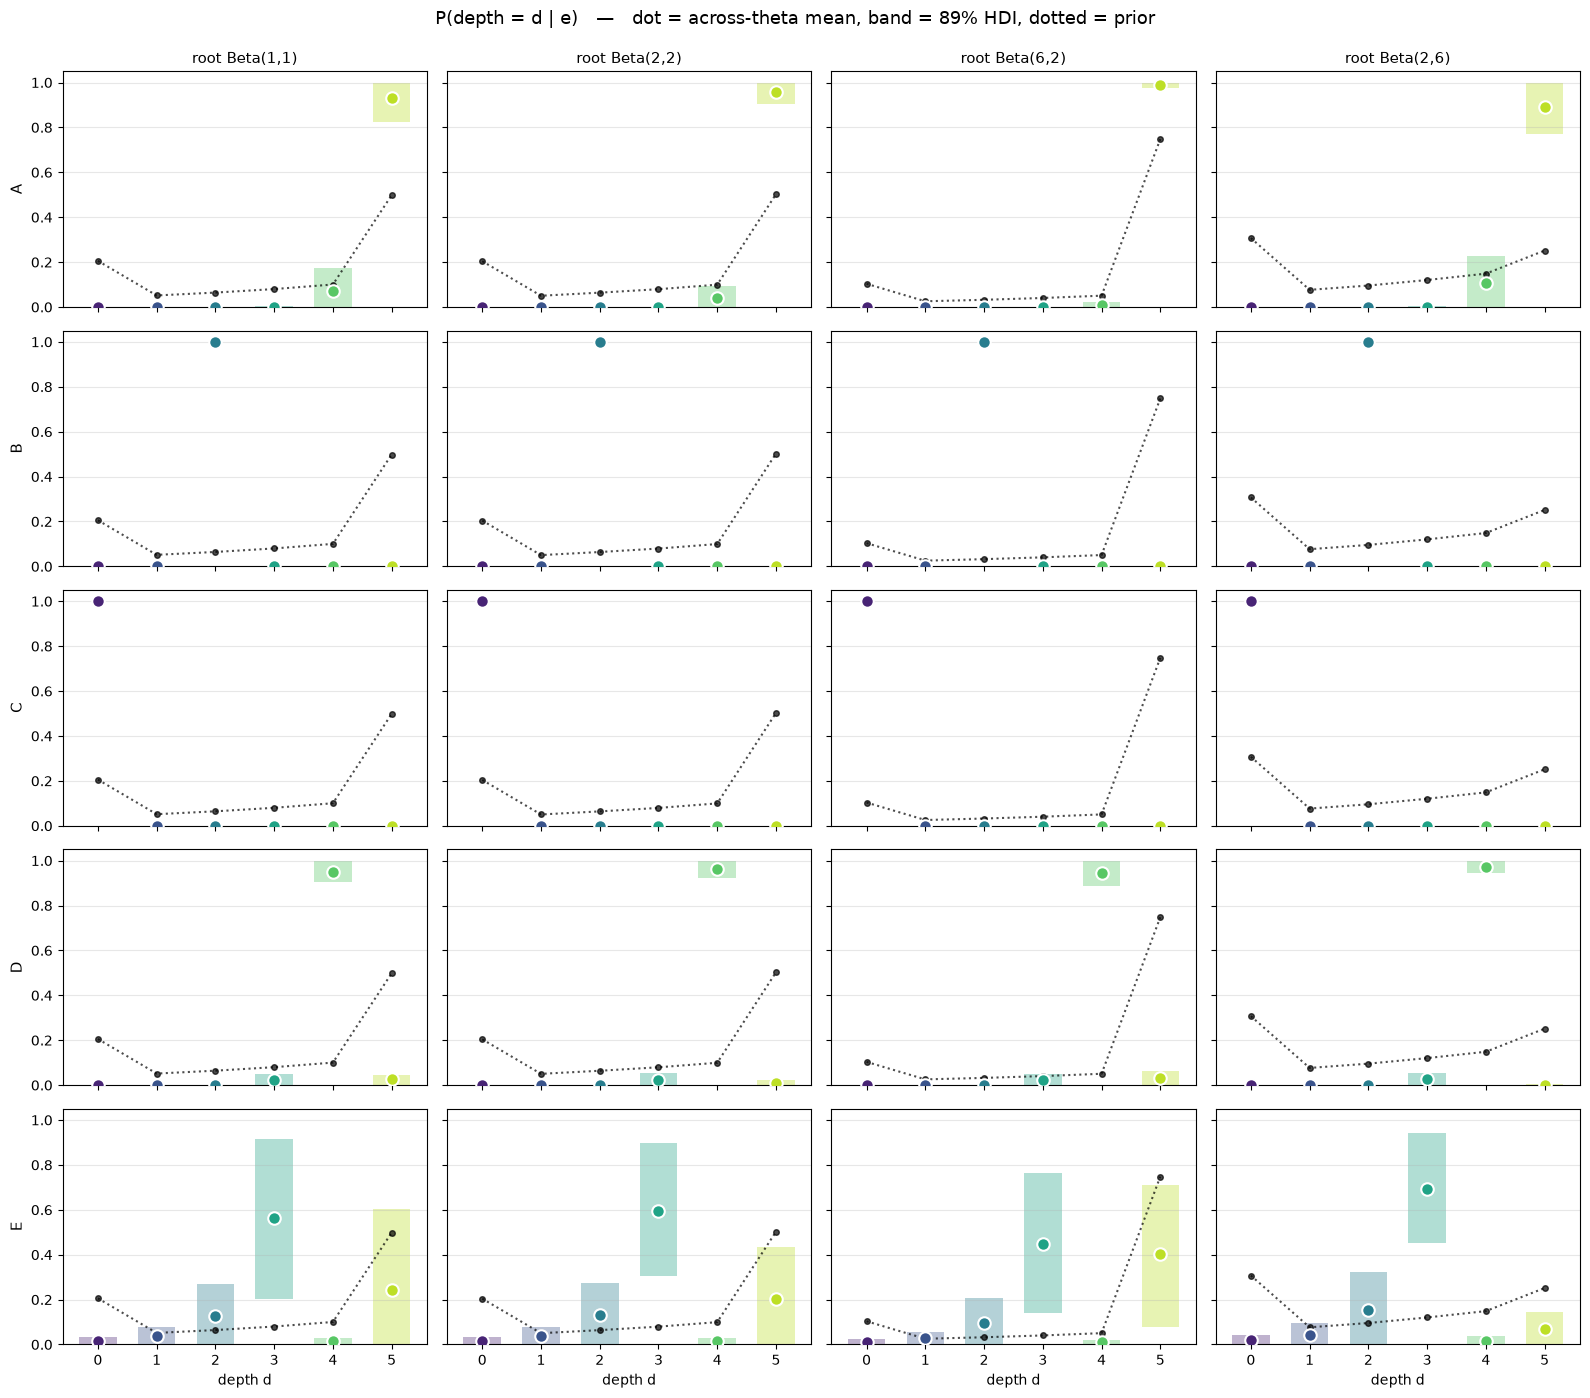

In [12]:
depth_colors = plt.cm.viridis(np.linspace(0.10, 0.90, L + 1))
fig, axes = plt.subplots(len(CASES), len(C_PRIOR_SWEEP), figsize=(16, 14), sharex=True, sharey=True)
xs = np.arange(L + 1); bh = 0.32
for i, (case_name, _) in enumerate(CASES):
    for j, (label, _) in enumerate(C_PRIOR_SWEEP):
        ax = axes[i, j]; r = results[case_name][label]
        per = r['P_dep_per_theta']; means = per.mean(0)
        lo, hi = hdi_from_samples(per, prob=HDI_PROB, axis=0)
        for d in range(L + 1):
            ax.fill_between([xs[d]-bh, xs[d]+bh], lo[d], hi[d], color=depth_colors[d], alpha=0.35, lw=0)
            ax.plot(xs[d], means[d], 'o', color=depth_colors[d], markersize=9,
                    markeredgecolor='white', markeredgewidth=1.5, zorder=3)
        ax.plot(xs, r['P_dep_prior'], 'k:o', lw=1.5, markersize=4, alpha=0.7)
        ax.set_ylim(0, 1.05); ax.set_xticks(xs)
        if i == 0: ax.set_title(f'root {label}', fontsize=11)
        if j == 0: ax.set_ylabel(case_name.split(':')[0], fontsize=11)
        if i == len(CASES) - 1: ax.set_xlabel('depth d')
        ax.grid(axis='y', alpha=0.3)
plt.suptitle(f'P(depth = d | e)   —   dot = across-theta mean, band = {int(HDI_PROB*100)}% HDI, dotted = prior',
             y=0.995, fontsize=13)
plt.tight_layout()
plt.savefig(FIG / f'sweep_depth_hdi{int(HDI_PROB*100)}.png', dpi=120, bbox_inches='tight')
plt.show()

### Reading the sweep

A coloured dot near its black dotted prior marker means the evidence isn't moving that quantity; far means it is; a wide HDI band means the answer depends sharply on which $\theta$ you condition on. Note that **per-level posteriors are not forced to be monotone** — under the generalised model a finer level can carry more posterior than the coarser level above it, because Condition 2B permits gaps. (Switch any `cfg_for(ab)` to `cfg_for(ab, strict=True)` to restore the monotonic belief property.)

## 9. Your own case

Replace the 0s/1s below with your judgements (order matches the Section 2 table), choose a root prior, and toggle `MY_STRICT` to compare the strict and generalised models. (The [live explorer](https://ai-cognition.org/cacophony-tool/) does the same interactively.)

In [13]:
MY_RESPONSES = [
    0,0,0,0,0,0,0,0,0,   # L1 Behavioural (9)
    0,0,0,0,0,0,0,        # L2 Computational functional (7)
    0,0,0,0,0,0,0,        # L3 Intrinsic causal-structure (7)
    0,0,0,0,0,0,          # L4 Organismic (6)
    0,0,0,0,0,0,0,0,      # L5 Organism-environment / 4E (8)
]
assert len(MY_RESPONSES) == N_IND, f'Expected {N_IND}; got {len(MY_RESPONSES)}'

MY_ROOT_PRIOR = (1.0, 1.0)   # try (2,2), (6,2), (2,6)
MY_STRICT = False            # True = Strict Supervenience Model (Condition 2A)

e_custom = np.asarray(MY_RESPONSES, dtype=int)
cfg_custom = cfg_for(MY_ROOT_PRIOR, strict=MY_STRICT)
prior_dep = prior_depth_distribution(cfg_custom, n_draws=N_DRAWS, seed=SEED)
prior_C   = prior_C_marginals(cfg_custom, n_draws=N_DRAWS, seed=SEED)
sc_custom = prior_predictive_score(e_custom, cfg_custom, level_of,
                                   n_draws=N_DRAWS, seed=SEED, return_per_theta=True)

print(f'Custom case   root = Beta{MY_ROOT_PRIOR}   strict = {MY_STRICT}')
print('Yes per level: ' + ', '.join(
    f'L{k+1}: {int(e_custom[level_of==k].sum())}/{int((level_of==k).sum())}' for k in range(L)))
print()
print(format_score(sc_custom, prior_depth=prior_dep, prior_C=prior_C))

Custom case   root = Beta(1.0, 1.0)   strict = False
Yes per level: L1: 0/9, L2: 0/7, L3: 0/7, L4: 0/6, L5: 0/8

Per-level posteriors P(C_i = 1 | e):
  C1: 0.000      prior = 0.499
  C2: 0.000      prior = 0.499
  C3: 0.000      prior = 0.499
  C4: 0.000      prior = 0.498
  C5: 0.000      prior = 0.498

Posterior over depth (highest active level):
  depth = 0: 1.000  ########################################    prior = 0.206
  depth = 1: 0.000      prior = 0.052
  depth = 2: 0.000      prior = 0.064
  depth = 3: 0.000      prior = 0.080
  depth = 4: 0.000      prior = 0.100
  depth = 5: 0.000      prior = 0.498

Most likely depth: 0


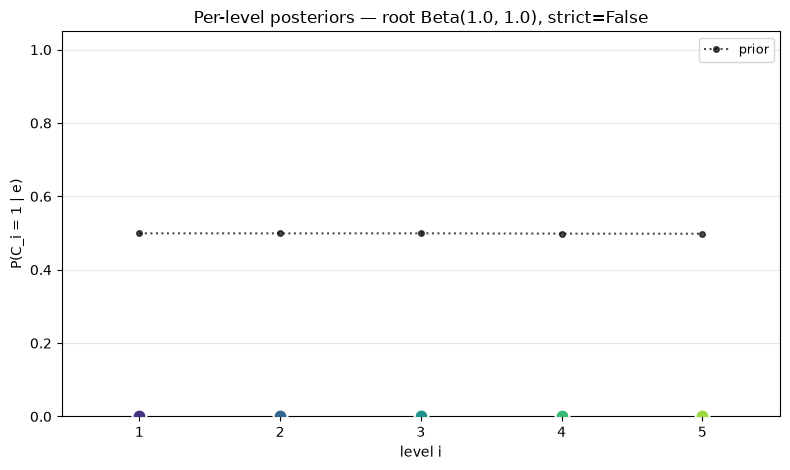

In [14]:
level_colors = plt.cm.viridis(np.linspace(0.15, 0.85, L))
fig, ax = plt.subplots(figsize=(8, 4.8))
per = sc_custom['P(C_i=1|e,theta)_per_draw']; means = per.mean(0)
lo, hi = hdi_from_samples(per, prob=HDI_PROB, axis=0)
xs = np.arange(1, L + 1)
for k in range(L):
    ax.fill_between([xs[k]-0.32, xs[k]+0.32], lo[k], hi[k], color=level_colors[k], alpha=0.35, lw=0)
    ax.plot(xs[k], means[k], 'o', color=level_colors[k], markersize=10,
            markeredgecolor='white', markeredgewidth=1.5, zorder=3)
ax.plot(xs, prior_C, 'k:o', lw=1.5, markersize=4, alpha=0.7, label='prior')
ax.set_xlabel('level i'); ax.set_ylabel('P(C_i = 1 | e)')
ax.set_title(f'Per-level posteriors — root Beta{MY_ROOT_PRIOR}, strict={MY_STRICT}')
ax.set_xticks(xs); ax.set_ylim(0, 1.05); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG / 'custom_case.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Overall credence as a weighted average across levels

Paper Section 7.3: writing $L^\ast$ for the **critical level** for consciousness, the overall credence that the system is conscious is

$$P(C \mid E) = \sum_{i=1}^{5} P(L^\ast = i) \cdot P(C_i \mid E).$$

The weights $P(L^\ast = i)$ are the **theoretical credences** — the degree of belief that Level $i$ is the correct level of description for consciousness, set by philosophical argument rather than by the system-level evidence. A computer scientist might concentrate credence on Level 2; a neuroscientist influenced by IIT on Level 3; a biologist influenced by Seth or Lane on Level 4; an enactivist on Level 5. `overall_credence` computes the weighted average per $\theta$-draw so the 89% HDI carries through.

In [15]:
MY_CREDENCES = np.array([0.3, 0.2, 0.1, 0.3, 0.1])   # P(L* = i), i = 1..5
assert abs(MY_CREDENCES.sum() - 1.0) < 1e-6

case_name, frac = CASES[4]
e_E = e_from_fractions(frac)
sc = prior_predictive_score(e_E, cfg_for((1.0, 1.0)), level_of, n_draws=N_DRAWS, seed=SEED,
                            return_per_theta=True)
per_theta_C = sc['P(C_i=1|e,theta)_per_draw']
mixed_per_theta = overall_credence(per_theta_C, MY_CREDENCES)
per_level_mean = per_theta_C.mean(0)
per_level_lo, per_level_hi = hdi_from_samples(per_theta_C, prob=HDI_PROB, axis=0)
mixed_mean = mixed_per_theta.mean()
mixed_lo, mixed_hi = hdi_from_samples(mixed_per_theta, prob=HDI_PROB)

print(f'Case: {case_name}   (generalised model, root Beta(1,1))')
print(f'Theoretical credences P(L*=i): {list(MY_CREDENCES)}\n')
for k in range(L):
    print(f'  C{k+1}: mean = {per_level_mean[k]:.3f},  {int(HDI_PROB*100)}% HDI = '
          f'[{per_level_lo[k]:.3f}, {per_level_hi[k]:.3f}]')
print(f'\nOverall credence P(C|E) = sum_i P(L*=i) P(C_i|E):  mean = {mixed_mean:.3f},  '
      f'{int(HDI_PROB*100)}% HDI = [{mixed_lo:.3f}, {mixed_hi:.3f}]')

Case: E: about half yes everywhere (the ambiguous one)   (generalised model, root Beta(1,1))
Theoretical credences P(L*=i): [np.float64(0.3), np.float64(0.2), np.float64(0.1), np.float64(0.3), np.float64(0.1)]

  C1: mean = 0.944,  89% HDI = [0.902, 0.985]
  C2: mean = 0.914,  89% HDI = [0.839, 0.987]
  C3: mean = 0.777,  89% HDI = [0.559, 0.970]
  C4: mean = 0.071,  89% HDI = [0.002, 0.151]
  C5: mean = 0.242,  89% HDI = [0.000, 0.604]

Overall credence P(C|E) = sum_i P(L*=i) P(C_i|E):  mean = 0.589,  89% HDI = [0.517, 0.672]


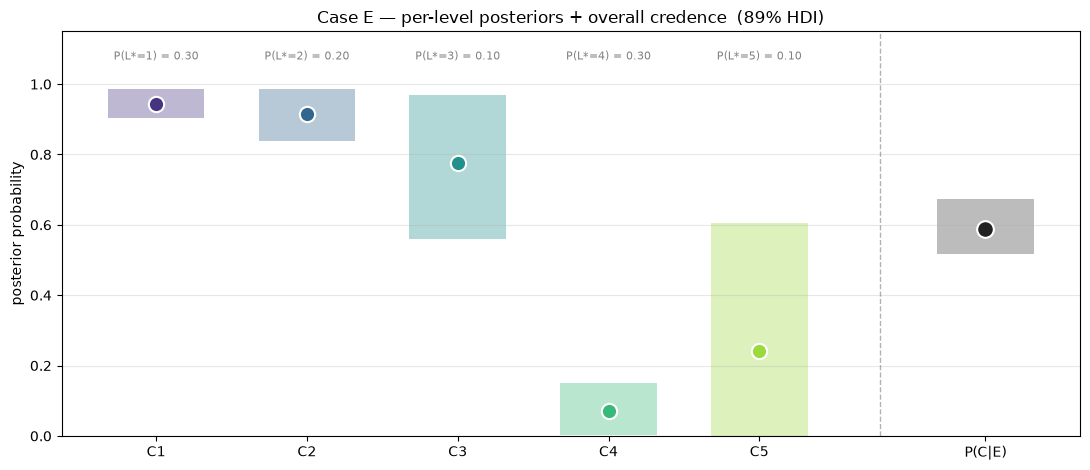

In [16]:
level_colors = plt.cm.viridis(np.linspace(0.15, 0.85, L)); MIX = '#222222'
fig, ax = plt.subplots(figsize=(11, 4.8)); bh = 0.32
for k in range(L):
    x = k + 1
    ax.fill_between([x-bh, x+bh], per_level_lo[k], per_level_hi[k], color=level_colors[k], alpha=0.35, lw=0)
    ax.plot(x, per_level_mean[k], 'o', color=level_colors[k], markersize=11,
            markeredgecolor='white', markeredgewidth=1.5, zorder=3)
    ax.annotate(f'P(L*={k+1}) = {MY_CREDENCES[k]:.2f}', xy=(x, 1.07), ha='center', fontsize=8, color='gray')
ax.axvline(L + 0.8, color='black', alpha=0.3, lw=1, ls='--')
mx = L + 1.5
ax.fill_between([mx-bh, mx+bh], mixed_lo, mixed_hi, color=MIX, alpha=0.30, lw=0)
ax.plot(mx, mixed_mean, 'o', color=MIX, markersize=12, markeredgecolor='white', markeredgewidth=1.5, zorder=3)
ax.set_xticks(list(range(1, L + 1)) + [mx]); ax.set_xticklabels([f'C{k+1}' for k in range(L)] + ['P(C|E)'])
ax.set_ylabel('posterior probability')
ax.set_title(f'Case E — per-level posteriors + overall credence  ({int(HDI_PROB*100)}% HDI)')
ax.set_ylim(0, 1.15); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / 'overall_credence_caseE.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Illustrative systems: head-to-head comparison

The five illustrative systems of the paper's Section 7.4 — Human, Fly, LLM-optimist, LLM-sceptic, and Thermostat — scored with equal theoretical credences $P(L^\ast = i) = 0.2$, root $\mathrm{Beta}(1,1)$, generalised model. The evidence vectors are fabricated by the authors to illustrate model behaviour (each embodies a viewpoint); the point is the *relative ordering* the model produces, not the specific numbers. The same systems, with the same vectors, are preloaded in the [live explorer](https://ai-cognition.org/cacophony-tool/).

In [17]:
SYSTEMS = {
    'Human': [1] * 37,
    'Fly': [
        0,0,0,1,1,0,1,0,1,  1,1,1,0,1,0,0,  1,1,1,0,1,0,0,  1,1,1,1,1,1,  1,1,1,1,1,1,1,1,
    ],
    'LLM-optimist': [
        1,1,1,1,1,0,0,1,1,  1,1,1,0,1,1,0,  0,0,0,0,0,0,0,  0,0,0,0,0,0,  0,0,0,0,0,0,0,0,
    ],
    'LLM-sceptic': [
        1,1,1,0,0,0,0,0,0,  0,0,0,0,0,0,0,  0,0,0,0,0,0,0,  0,0,0,0,0,0,  0,0,0,0,0,0,0,0,
    ],
    'Thermostat': [
        0,0,0,0,1,0,0,0,0,  0,0,0,0,0,0,0,  0,0,0,0,0,0,0,  0,1,0,0,0,0,  0,0,0,0,0,0,0,0,
    ],
}
SYSTEM_COLOURS = {'Human': '#0b57d0', 'Fly': '#146c2e', 'LLM-optimist': '#d56e0c',
                  'LLM-sceptic': '#b3261e', 'Thermostat': '#5f6368'}
EQUAL_CRED = np.full(L, 1 / L)
for name, e in SYSTEMS.items():
    assert len(e) == N_IND

system_results = {}
for name, e in SYSTEMS.items():
    sc = prior_predictive_score(np.asarray(e, int), cfg_for((1.0, 1.0)), level_of,
                                n_draws=N_DRAWS, seed=SEED, return_per_theta=True)
    per = sc['P(C_i=1|e,theta)_per_draw']
    mixed = overall_credence(per, EQUAL_CRED)
    ml, mh = hdi_from_samples(mixed, prob=HDI_PROB)
    system_results[name] = {'per_level_mean': per.mean(0),
                            'per_level_hdi': hdi_from_samples(per, prob=HDI_PROB, axis=0),
                            'mixed_mean': mixed.mean(), 'mixed_lo': ml, 'mixed_hi': mh}

hdr = f'{"system":<14}  ' + '  '.join(f'C{k+1}' + '   ' for k in range(L)) + '   P(C|E)  [89% HDI]'
print(hdr); print('-' * len(hdr))
for name, r in system_results.items():
    cells_ = '  '.join(f'{v:.3f}' for v in r['per_level_mean'])
    print(f'{name:<14}  {cells_}    {r["mixed_mean"]:.3f}  [{r["mixed_lo"]:.3f}, {r["mixed_hi"]:.3f}]')

system          C1     C2     C3     C4     C5      P(C|E)  [89% HDI]
---------------------------------------------------------------------
Human           1.000  1.000  1.000  1.000  1.000    1.000  [1.000, 1.000]
Fly             0.744  0.858  0.944  1.000  1.000    0.909  [0.859, 0.969]
LLM-optimist    1.000  0.969  0.000  0.000  0.000    0.394  [0.387, 0.400]
LLM-sceptic     0.026  0.000  0.000  0.000  0.000    0.005  [0.000, 0.010]
Thermostat      0.000  0.000  0.000  0.000  0.000    0.000  [0.000, 0.000]


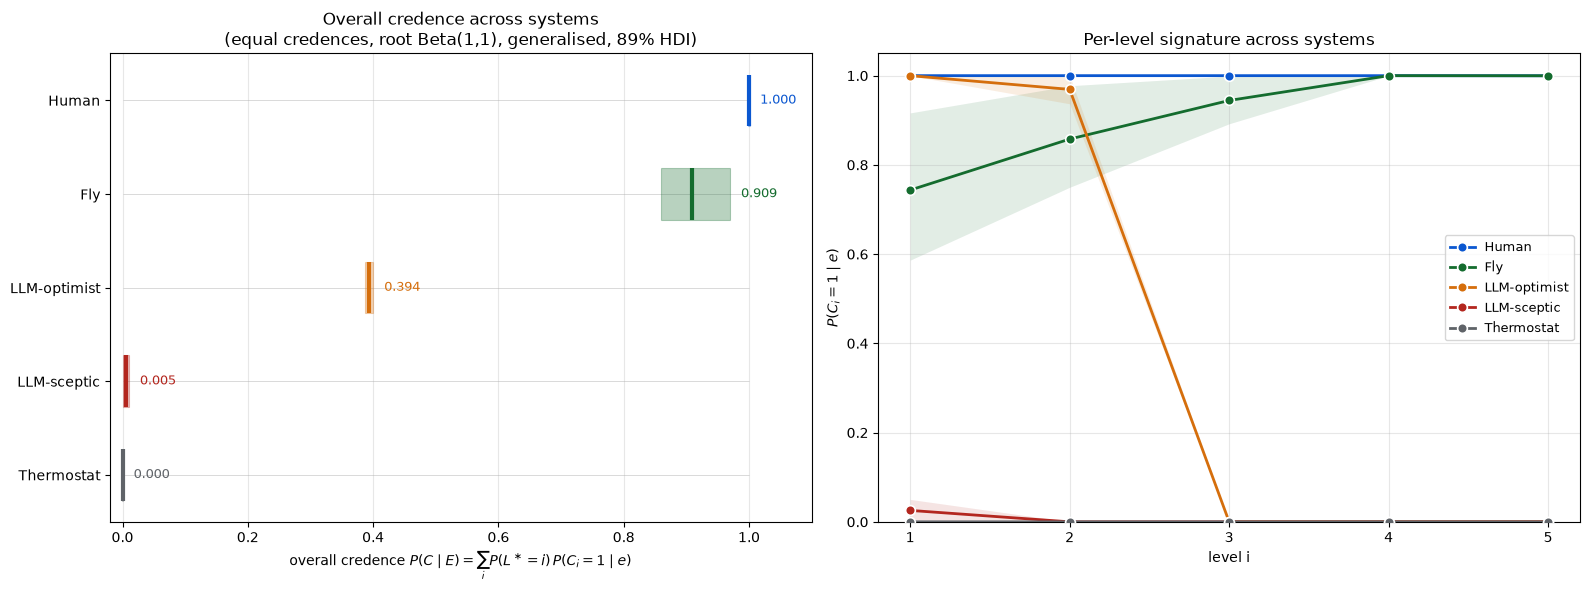

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
names = list(SYSTEMS.keys())

ax = axes[0]
order = sorted(names, key=lambda n: system_results[n]['mixed_mean'], reverse=True)
y = np.arange(len(order)); bh = 0.55
for yi, name in zip(y, order):
    r = system_results[name]; c = SYSTEM_COLOURS[name]
    lo, mean, hi = r['mixed_lo'], r['mixed_mean'], r['mixed_hi']
    ax.hlines(yi, 0, 1, colors='lightgrey', lw=0.6, zorder=1)
    span_lo, span_hi = (mean - 0.0015, mean + 0.0015) if hi - lo < 0.003 else (lo, hi)
    ax.barh(yi, span_hi - span_lo, left=span_lo, height=bh, color=c, alpha=0.30,
            edgecolor=c, linewidth=0.8, zorder=2)
    ax.vlines(mean, yi - bh/2, yi + bh/2, colors=c, lw=3, zorder=4)
    ax.annotate(f'{mean:.3f}', xy=(max(mean, hi), yi), xytext=(8, 0),
                textcoords='offset points', va='center', fontsize=9, color=c)
ax.set_yticks(y); ax.set_yticklabels(order); ax.invert_yaxis()
ax.set_xlim(-0.02, 1.10); ax.set_xlabel(r'overall credence $P(C\mid E) = \sum_i P(L^\ast{=}i)\,P(C_i{=}1\mid e)$')
ax.set_title('Overall credence across systems\n(equal credences, root Beta(1,1), generalised, 89% HDI)')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
level_colors = plt.cm.viridis(np.linspace(0.15, 0.85, L)); xs = np.arange(1, L + 1)
for name in names:
    r = system_results[name]; c = SYSTEM_COLOURS[name]
    lo, hi = r['per_level_hdi']
    ax.plot(xs, r['per_level_mean'], 'o-', color=c, lw=2, markersize=7,
            markeredgecolor='white', markeredgewidth=1.2, label=name, zorder=3)
    ax.fill_between(xs, lo, hi, color=c, alpha=0.12, lw=0)
ax.set_xticks(xs); ax.set_xlabel('level i'); ax.set_ylabel(r'$P(C_i=1\mid e)$')
ax.set_title('Per-level signature across systems'); ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3); ax.legend(loc='center right', fontsize=9)
plt.tight_layout()
plt.savefig(FIG / 'illustrative_systems_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### Reading the comparison

The ordering follows from how the evidence vectors were built, not as an independent finding. Note that a system's per-level signature need not be monotone — under the generalised model a finer level can carry posterior without the coarser level above it. Switching `cfg_for((1.0,1.0))` to `cfg_for((1.0,1.0), strict=True)` in the cell above imposes Condition 2A and restores the monotone, staircase-only behaviour (compare the Fly's flat 6/6 Level 4 and 8/8 Level 5 blocks with its sparser upper levels to see the difference at its starkest).